# IoT Smart Incubator Monitoring System
Name : Sri Mohnish Kannappan Jeyaprakash
Course:Medical Systems Engineering

# 1. Project Overview
This project simulates a **Neonatal Incubator Monitoring System**. It integrates embedded hardware simulation (Tinkercad) with a Python-based central monitoring station.
Objective: Monitor vital signs (Temperature) and trigger safety alarms.
* **Tools Used:** Arduino (Simulation), Python (Pandas, Matplotlib, Tkinter).

# 2. Hardware Architecture
The circuit uses an **Arduino Uno** with a **TMP36 Sensor**.
 **Red LED:** High Fever Alert (>37.5°C)
 **Blue LED:** Hypothermia Alert (<36.5°C)
 **Green LED:** Stable Condition

# 2.1 Embedded Firmware (Arduino C++) ( Tinkercad circuit image "circuit_diagram.png" in the folder)
The following code was deployed to the ATmega328P microcontroller to handle sensor data acquisition and safety logic.

```cpp
// Medical Incubator Firmware v1.0
const int sensorPin = A0;
const int redLED = 13;   // High Temp Alarm
const int greenLED = 12; // Normal Status
const int blueLED = 11;  // Low Temp Alarm

void setup() {
  pinMode(redLED, OUTPUT);
  pinMode(greenLED, OUTPUT);
  pinMode(blueLED, OUTPUT);
  pinMode(sensorPin, INPUT);
  Serial.begin(9600);
}

void loop() {
  int reading = analogRead(sensorPin); 
  
  // Convert Analog (0-1023) to Voltage (0-5V) to Celsius
  float voltage = reading * 5.0;
  voltage /= 1024.0; 
  float temperatureC = (voltage - 0.5) * 100;

  // Telemetry Format: "Temp:36.5"
  Serial.print("Temp:"); 
  Serial.println(temperatureC);

  // Safety Logic
  if (temperatureC > 37.5) {
    digitalWrite(redLED, HIGH);  // Hyperthermia Alert
    digitalWrite(greenLED, LOW);
    digitalWrite(blueLED, LOW);
  }
  else if (temperatureC < 36.5) {
    digitalWrite(redLED, LOW);
    digitalWrite(greenLED, LOW);
    digitalWrite(blueLED, HIGH); // Hypothermia Alert
  }
  else {
    digitalWrite(redLED, LOW);
    digitalWrite(greenLED, HIGH); // Stable
    digitalWrite(blueLED, LOW);
  }
  delay(1000);
}
```

In [2]:
%pip install matplotlib pandas

  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached pandas-2.3.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp313-cp313-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
  Using cached numpy-2.4.0-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached pillow-12.1.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.1-py3-none-any.whl.metadata (5.6 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached pandas-2.3.3-cp313-cp313-win_amd64.whl (11.0 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-

# Simulating the raw data intake from the Serial Monitor

In [3]:

# CODE BLOCK 1: Data Cleaning Pipeline
import pandas as pd

# Simulating the raw data intake from the Serial Monitor
raw_data_sample = ["Temp:36.5", "Temp:37.1", "Temp:45.7"]

print("Processing Raw Telemetry Data...")

df = pd.read_csv("incubator_log.csv")
print("Data successfully loaded. Sample rows:")
print(df.head())

Processing Raw Telemetry Data...
Data successfully loaded. Sample rows:
   TimeID  Temperature
0       0         45.7
1       1         45.7
2       2         45.7
3       3         45.7
4       4         45.7


## 3. Plotting the changes in Temperature over time using matplotlib:

--- PATIENT REPORT ---
   TimeID  Temperature
0       0         45.7
1       1         45.7
2       2         45.7
3       3         45.7
4       4         45.7

Average Temp: 32.63°C
Max Fever:    45.70°C
Lowest Temp:  24.71°C

CRITICAL ALERT: 12 readings were above 37.5°C!


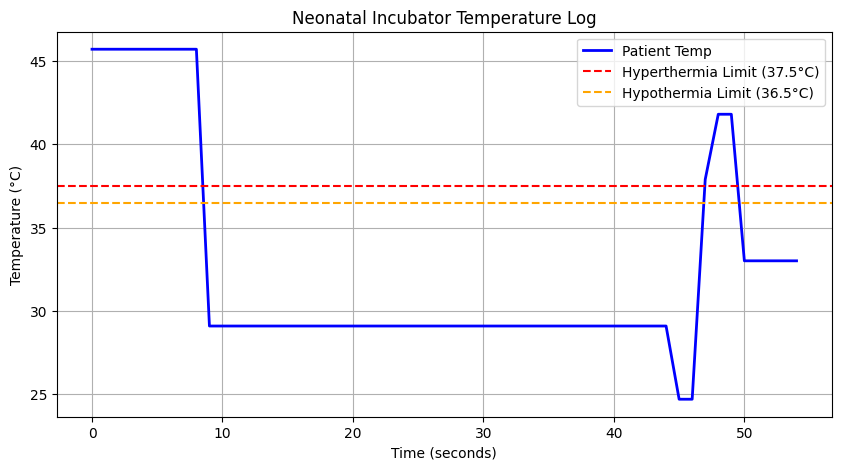

In [6]:
import matplotlib.pyplot as plt

# 1. LOAD DATA

df = pd.read_csv("incubator_log.csv")

print("--- PATIENT REPORT ---")
print(df.head()) #

# 2. STATISTICAL ANALYSIS

avg_temp = df["Temperature"].mean()
max_temp = df["Temperature"].max()
min_temp = df["Temperature"].min()

print(f"\nAverage Temp: {avg_temp:.2f}°C")
print(f"Max Fever:    {max_temp:.2f}°C")
print(f"Lowest Temp:  {min_temp:.2f}°C")

# 3. SAFETY CHECK

fever_events = df[df["Temperature"] > 37.5]
print(f"\nCRITICAL ALERT: {len(fever_events)} readings were above 37.5°C!")

# 4. VISUALIZATION (The Graph)
plt.figure(figsize=(10, 5)) 

# Plot the patient data
plt.plot(df["TimeID"], df["Temperature"], label="Patient Temp", color="blue", linewidth=2)


plt.axhline(y=37.5, color='r', linestyle='--', label="Hyperthermia Limit (37.5°C)")
plt.axhline(y=36.5, color='orange', linestyle='--', label="Hypothermia Limit (36.5°C)")

# Labels and Title
plt.title("Neonatal Incubator Temperature Log")
plt.xlabel("Time (seconds)")
plt.ylabel("Temperature (°C)")
plt.legend() 
plt.grid(True) 

# Show the graph
plt.show()

## 4. GUI Dashboard 
A Tkinter-based application was developed to allow medical staff to interact with the data.

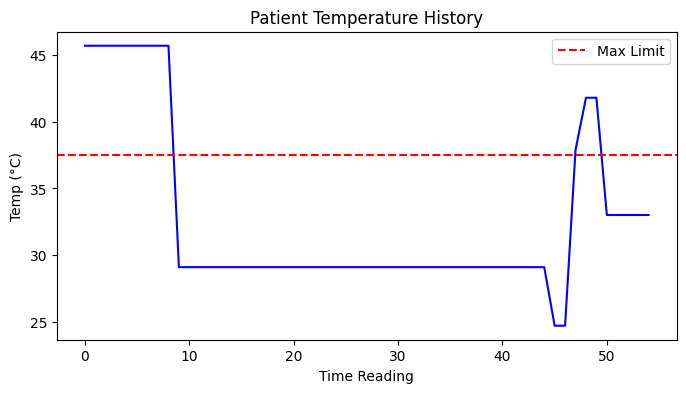

In [5]:
import tkinter as tk
from tkinter import messagebox
import pandas as pd
import matplotlib.pyplot as plt


class IncubatorApp:
    def __init__(self, root):
        self.root = root
        self.root.title("IoT Incubator Monitor")
        self.root.geometry("400x300") 
        
        # 1. HEADER
        self.header_label = tk.Label(root, text="Neonatal Monitoring System", 
                                     font=("Arial", 16, "bold"), fg="blue")
        self.header_label.pack(pady=10)

        # 2. STATUS DISPLAY
        self.status_label = tk.Label(root, text="Status: Waiting for Data...", 
                                     font=("Arial", 12), fg="gray")
        self.status_label.pack(pady=20)

        # 3. BUTTONS
        self.btn_load = tk.Button(root, text="Load Patient Log", 
                                  command=self.load_data, bg="lightgray", width=20)
        self.btn_load.pack(pady=5)

        self.btn_graph = tk.Button(root, text="View Temperature Chart", 
                                   command=self.show_graph, state="disabled", width=20)
        self.btn_graph.pack(pady=5)

        
        self.df = None

    
    def load_data(self):
        try:
            self.df = pd.read_csv("incubator_log.csv")
            
            
            max_temp = self.df["Temperature"].max()
        
            if max_temp > 37.5:
                self.status_label.config(text=f"WARNING: Fever Detected ({max_temp}°C)", fg="red")
            else:
                self.status_label.config(text=f"Status: Patient Stable ({max_temp}°C)", fg="green")
            
          
            self.btn_graph.config(state="normal", bg="lightblue")
            messagebox.showinfo("Success", "Patient data loaded successfully.")
            
        except FileNotFoundError:
            messagebox.showerror("Error", "incubator_log.csv not found!")

  
    def show_graph(self):
        if self.df is None:
            return
            
        plt.figure(figsize=(8, 4))
        plt.plot(self.df["TimeID"], self.df["Temperature"], color='blue')
        plt.axhline(y=37.5, color='r', linestyle='--', label="Max Limit")
        plt.title("Patient Temperature History")
        plt.xlabel("Time Reading")
        plt.ylabel("Temp (°C)")
        plt.legend()
        plt.show()


if __name__ == "__main__":
    root = tk.Tk() 
    app = IncubatorApp(root) 
    root.mainloop() 

## 5. Conclusion & Future Scope
This project successfully demonstrated a **closed-loop medical monitoring system**. By simulating the hardware layer in Tinkercad and processing the telemetry in Python, we achieved:
1.  **Real-time Safety:** Immediate visual feedback via LEDs for fever/hypothermia.
2.  **Data Persistence:** Automated logging of patient vitals to CSV for audit trails.
3.  **Decision Support:** A GUI dashboard allowing medical staff to visualize trends.

**Future Improvements:**
In a real-world deployment, the Serial connection would be replaced by **MQTT (Wi-Fi)** for wireless monitoring, and the CSV storage would be upgraded to an **SQL Database** for security.